In [10]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numba import cuda

### Медианный фильтр CUDA

In [11]:
@cuda.jit
def median_cuda(source, result, h, w):
    y, x = cuda.grid(2)
    if y >= h or x >= w:
        return
    if x == 0 or y == 0 or x == w - 1 or y == h - 1:
        result[y, x] = source[y, x]
        return
    values = cuda.local.array(9, dtype=np.uint8)

    index = 0
    for dy in range(-1, 2):
        for dx in range(-1, 2):
            values[index] = source[y + dy, x + dx]
            index += 1
    for i in range(9):
        for j in range(0, 8 - i):
            if values[j] > values[j + 1]:
                temp = values[j]
                values[j] = values[j + 1]
                values[j + 1] = temp
    result[y, x] = values[4]

### Загрузка изображения

In [12]:
def load_grayscale(path):
    image = Image.open(path).convert("L")
    return np.array(image, dtype=np.uint8)

### Шум salt & pepper

In [13]:
def apply_impulse_noise(image, amount=0.08):
    damaged = image.copy()
    random_values = np.random.random(image.shape)
    black = random_values < amount / 2
    white = random_values > 1 - amount / 2
    damaged[black] = 0
    damaged[white] = 255
    return damaged

### CPU

In [14]:
def median_cpu(image):
    h, w = image.shape
    filtered = image.copy()
    for y in range(1, h - 1):
        for x in range(1, w - 1):
            fragment = []
            for dy in range(-1, 2):
                for dx in range(-1, 2):
                    fragment.append(image[y + dy, x + dx])
            fragment.sort()
            filtered[y, x] = fragment[4]
    return filtered

### GPU

In [15]:
def median_gpu(image):
    h, w = image.shape
    output = np.zeros_like(image)

    d_source = cuda.to_device(image)
    d_output = cuda.to_device(output)

    threads = (16, 16)
    blocks = ((h + threads[0] - 1) // threads[0], (w + threads[1] - 1) // threads[1])

    median_cuda[blocks, threads](d_source, d_output, h, w)

    cuda.synchronize()
    start = time.time()

    median_cuda[blocks, threads](d_source, d_output, h, w)
    cuda.synchronize()

    elapsed = time.time() - start
    output = d_output.copy_to_host()

    return output, elapsed

### Метрики

In [16]:
def calculate_mse(original, processed):
    diff = original.astype(np.float32) - processed.astype(np.float32)
    return np.mean(diff * diff)


def calculate_psnr(original, processed):
    error = calculate_mse(original, processed)
    if error == 0:
        return 100
    return 20 * np.log10(255.0 / np.sqrt(error))

In [17]:
def draw_results(original, noisy, cpu_img, gpu_img):
    fig = plt.figure(figsize=(14, 8))

    ax1 = fig.add_subplot(2, 2, 1)
    ax1.set_title("Исходное изображение")
    ax1.imshow(original, cmap="gray")
    ax1.axis("off")

    ax2 = fig.add_subplot(2, 2, 2)
    ax2.set_title("Изображение с шумом")
    ax2.imshow(noisy, cmap="gray")
    ax2.axis("off")

    ax3 = fig.add_subplot(2, 2, 3)
    ax3.set_title("Результат CPU")
    ax3.imshow(cpu_img, cmap="gray")
    ax3.axis("off")

    ax4 = fig.add_subplot(2, 2, 4)
    ax4.set_title("Результат CUDA")
    ax4.imshow(gpu_img, cmap="gray")
    ax4.axis("off")

    plt.tight_layout()
    plt.show()


def draw_difference(cpu_img, gpu_img):

    delta = np.abs(cpu_img.astype(np.int16) - gpu_img.astype(np.int16))

    plt.figure(figsize=(6, 5))
    plt.title("Карта различий")
    plt.imshow(delta, cmap="hot")
    plt.colorbar()
    plt.axis("off")
    plt.show()

### Основная функция


Эксперимент по восстановлению изображения
---------------------------------------------
Графический процессор: Tesla T4
Размер изображения: 3840 x 2160
Уровень шума: 0.08
---------------------------------------------
Запуск последовательной фильтрации...
Последовательная фильтрация завершена

Запуск фильтрации CUDA...
Фильтрация CUDA завершена

Статистика
---------------------------------------------
Время выполнения на CPU: 25.556950 sec
Время выполнения на GPU: 0.003955 sec
Ускорение: 6461.73x
Результаты совпадают: True

Показатели качества
---------------------------------------------
PSNR зашумлённого изображения: 14.350
PSNR результата CPU: 41.381
PSNR результата GPU: 41.381


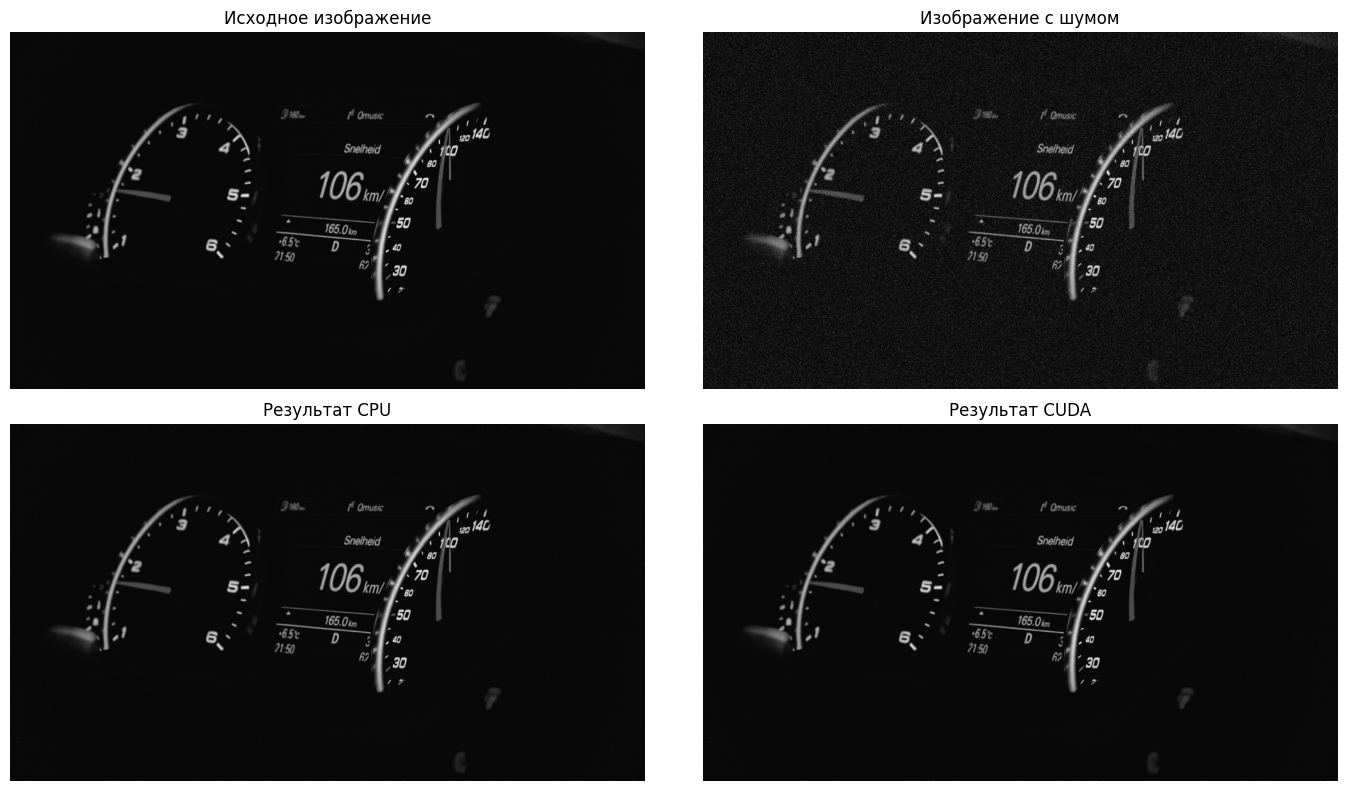

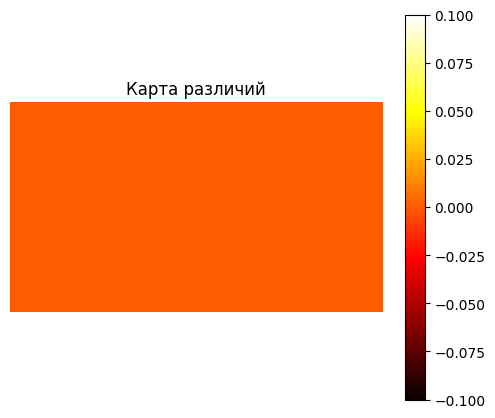

In [18]:
def run():

    if not cuda.is_available():
        raise RuntimeError("Устройство CUDA не обнаружено")

    device = cuda.get_current_device()

    print()
    print("Эксперимент по восстановлению изображения")
    print("-" * 45)
    print(f"Графический процессор: {device.name}")

    image = load_grayscale("/content/Спидометр.jpg")
    h, w = image.shape

    print(f"Размер изображения: {w} x {h}")

    noise_level = 0.08

    print(f"Уровень шума: {noise_level}")
    print("-" * 45)

    corrupted = apply_impulse_noise(image, noise_level)

    print("Запуск последовательной фильтрации...")

    cpu_start = time.time()
    cpu_result = median_cpu(corrupted)
    cpu_time = time.time() - cpu_start

    print("Последовательная фильтрация завершена")
    print()
    print("Запуск фильтрации CUDA...")

    gpu_result, gpu_time = median_gpu(corrupted)

    print("Фильтрация CUDA завершена")
    print()
    print("Статистика")
    print("-" * 45)
    print(f"Время выполнения на CPU: {cpu_time:.6f} sec")
    print(f"Время выполнения на GPU: {gpu_time:.6f} sec")
    print(f"Ускорение: {cpu_time / gpu_time:.2f}x")

    identical = np.array_equal(cpu_result, gpu_result)

    print(f"Результаты совпадают: {identical}")
    print()
    print("Показатели качества")
    print("-" * 45)
    print(f"PSNR зашумлённого изображения: " f"{calculate_psnr(image, corrupted):.3f}")
    print(f"PSNR результата CPU: " f"{calculate_psnr(image, cpu_result):.3f}")
    print(f"PSNR результата GPU: " f"{calculate_psnr(image, gpu_result):.3f}")

    draw_results(image, corrupted, cpu_result, gpu_result)
    draw_difference(cpu_result, gpu_result)

run()